In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sklearn

In [17]:
import os
data = "./DR_working"
print(os.listdir(data))

['Healthy', 'Mild DR', 'Moderate DR', 'Proliferate DR', 'Severe DR']


In [3]:
import os

for root, dirs, files in os.walk(data):
    print(root)

C:\SIH\DR_working
C:\SIH\DR_working\Healthy
C:\SIH\DR_working\Mild DR
C:\SIH\DR_working\Moderate DR
C:\SIH\DR_working\Proliferate DR
C:\SIH\DR_working\Severe DR


In [4]:
import os

image_extension = (".png")

total_images = 0

for root, dirs, files in os.walk(data):
    images = [
        f for f in files
        if f.lower().endswith(image_extension)
    ]

    if images:
        print(os.path.basename(root), ":", len(images))

        total_images += len(images)

print("\nTotal images:", total_images)

Healthy : 1000
Mild DR : 370
Moderate DR : 900
Proliferate DR : 290
Severe DR : 190

Total images: 2750


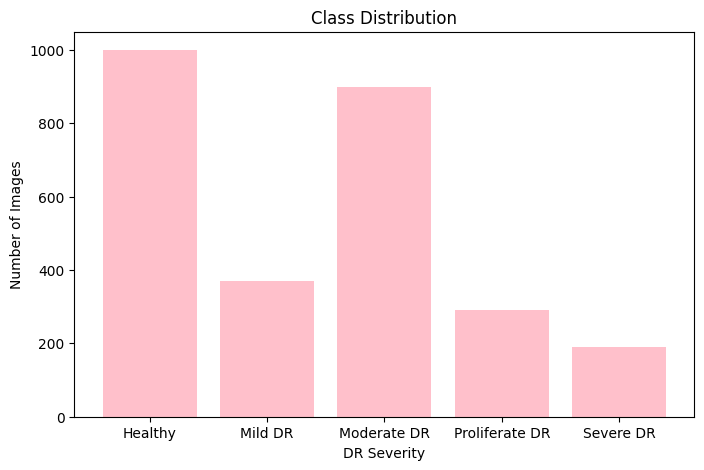

In [5]:
import matplotlib.pyplot as plt

counts = []
classes = os.listdir(data)
for cls in classes:
    folder = os.path.join(data, cls)

    count = len([
        f for f in os.listdir(folder)
        if f.lower().endswith(('.png'))
    ])

    counts.append(count)

plt.figure(figsize=(8,5))
plt.bar(classes, counts, color='pink')
plt.xlabel("DR Severity")
plt.ylabel("Number of Images")
plt.title("Class Distribution")
plt.xticks()
plt.show()

In [6]:
from PIL import Image
import os

image_extension = ( ".png" )

corrupted = []

for root, dirs, files in os.walk(data):

    for file in files:

        if file.lower().endswith(image_extension):

            path = os.path.join(root, file)

            try:
                img = Image.open(path)
                img.verify()

            except Exception:
                corrupted.append(path)

print("Corrupted images:", len(corrupted))

for path in corrupted[:20]:
    print(path)

Corrupted images: 0


In [7]:
from PIL import Image

def standardize_to_rgb(img_path):
    with Image.open(img_path) as img:
        # If RGBA, composite over a white background
        if img.mode in ('RGBA', 'LA'):
            background = Image.new('RGB', img.size, (255, 255, 255))

            return background
        return img.convert('RGB')

In [8]:
from collections import Counter
import os
from PIL import Image

dimensions = []

for root, dirs, files in os.walk(data):
    for file in files:
        if file.lower().endswith(image_extension):
            path = os.path.join(root, file)
            try:
                with Image.open(path) as img:
                    dimensions.append(img.size)
            except Exception as e:
                print(f"Could not process {path}: {e}")

dimension_counts = Counter(dimensions)

for dimension, count in dimension_counts.most_common(10):
    print(dimension, count)

(256, 256) 2750


In [9]:
import numpy as np
from PIL import Image
import os

# Assuming 'data' and 'image_extension' are defined in previous cells
# Let's find an image path to load 'img' for demonstration purposes
image_path = None
for root, _, files in os.walk(data):
    for file in files:
        if file.lower().endswith(image_extension):
            image_path = os.path.join(root, file)
            break
    if image_path:
        break

if image_path:
    img = Image.open(image_path) # Load the image into 'img'
    img = np.array(img) / 255.0  # Convert to numpy array before division and then scale
else:
    print("Error: No image found to process.")


In [12]:
%pip install opencv-python

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


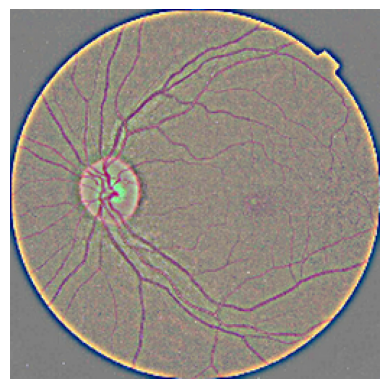

In [13]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

def crop_black_borders(image):

    gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)

    mask = gray > 10

    coords = np.argwhere(mask)

    if coords.size == 0:
        return image

    y_min, x_min = coords.min(axis=0)
    y_max, x_max = coords.max(axis=0)

    return image[y_min:y_max+1, x_min:x_max+1]

# Find an image path to demonstrate the function
image_path = None
for root, _, files in os.walk(data):
    for file in files:
        if file.lower().endswith(image_extension):
            image_path = os.path.join(root, file)
            break
    if image_path:
        break

if image_path:
    img = cv2.imread(image_path)
    if img is not None:
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        cropped = crop_black_borders(img)

        plt.imshow(cropped)
        plt.axis("off")
        plt.show()
    else:
        print(f"Error: Could not load image from {image_path}")
else:
    print("Error: No image found in the specified data directory to demonstrate.")

In [15]:
%pip install torch torchvision

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/1.4 MB ? eta -:--:--
   ------- -------------------------------- 0.3/1.4 MB ? eta -:--:--
   ---------------------------------------- 1.4/1.4 MB 4.7 MB/s  0:00:00
   ---------------------------------------- 0.0/124.1 MB ? eta -:--:--
   ---------------------------------------- 1.3/124.1 MB 6.1 MB/s eta 0:00:21
    --------------------------------------- 2.9/124.1 MB 7.3 MB/s eta 0:00:17
   - -------------------------------------- 3.9/124.1 MB 6.9 MB/s eta 0:00:18
   - -------------------------------------- 5.8/124.1 MB 6.9 MB/s eta 0:00:18
   -- ------------------------------------- 6.8/124.1 MB 7.0 MB/s eta 0:00:17
   -- ------------------------------------- 8.4/124.1 MB 7.0 MB/s eta 0:00:17
   --- ------------------------------------ 10.2/124.1 MB 7.1 MB/s eta 0:00:16
   --- ------------------------------------ 11.5/124.1 MB 7.0 MB/s eta 0:00:17
   ---- ------


[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [16]:
from torchvision.datasets import ImageFolder
import torchvision.transforms as transforms

CLASS_TO_IDX = {
    "Healthy": 0,
    "Mild DR": 1,
    "Moderate DR": 2,
    "Severe DR": 3,
    "Proliferate DR": 4
}

class CustomDRDataset(ImageFolder):

    def find_classes(self, directory):

        classes = list(CLASS_TO_IDX.keys())

        class_to_idx = CLASS_TO_IDX

        return classes, class_to_idx

# Define the transformation pipeline
transform = transforms.Compose([
    transforms.Resize((224, 224)), # Resize images to a common size
    transforms.ToTensor(),         # Convert images to PyTorch tensors
    transforms.Normalize(          # Normalize pixel values
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

dataset = CustomDRDataset(
    root=data, # Use the 'data' variable for the dataset root
    transform=transform
)
print("Classes:", dataset.classes)
print("Mapping:", dataset.class_to_idx)

Classes: ['Healthy', 'Mild DR', 'Moderate DR', 'Severe DR', 'Proliferate DR']
Mapping: {'Healthy': 0, 'Mild DR': 1, 'Moderate DR': 2, 'Severe DR': 3, 'Proliferate DR': 4}
